In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("tested.csv")

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,0,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Sex       418 non-null    int32  
 3   Age       418 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      418 non-null    float64
 7   Embarked  418 non-null    int32  
dtypes: float64(2), int32(2), int64(4)
memory usage: 23.0 KB


In [6]:
# to get ranges of dataset

data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


# correlation heatmap

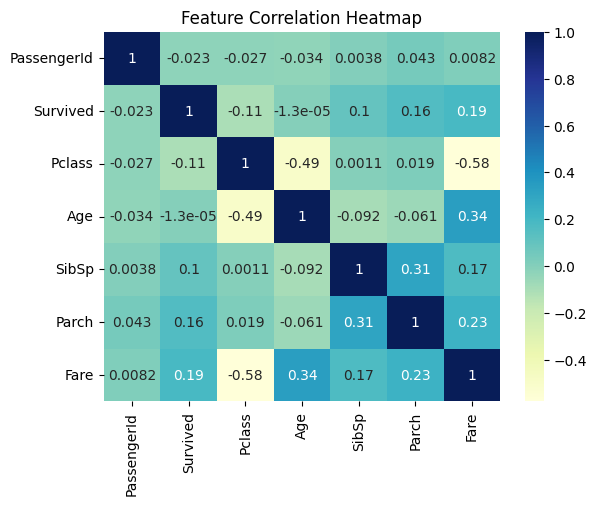

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only keep numeric columns for correlation
numeric_data = data.select_dtypes(include='number')

# Plot correlation heatmap
sns.heatmap(numeric_data.corr(), cmap="YlGnBu", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
print(data.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


# DATA PREPROCESSING

In [13]:
# Drop columns that are less useful
data.drop(['Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1, inplace=True, errors='ignore')

In [15]:
# Fill missing values
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Fare'] = data['Fare'].fillna(data['Fare'].median())

In [18]:
# Encode categorical features

from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])  # male:1, female:0
data['Embarked'] = le.fit_transform(data['Embarked'])


In [19]:
# Scale numerical features

scaler = StandardScaler()
data[['Age', 'Fare']] = scaler.fit_transform(data[['Age', 'Fare']])

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit

# Make a copy to avoid modifying original
data_copy = data.copy()

# Encode 'Sex' for stratification
data_copy['Sex'] = data_copy['Sex'].map({'male': 0, 'female': 1})

# Initialize stratified shuffle split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform split using only one stratification column (usually 'Survived' is enough)
for train_indices, test_indices in split.split(data_copy, data_copy["Survived"]):
    strat_train_set = data_copy.loc[train_indices]
    strat_test_set = data_copy.loc[test_indices]


# Exploratory Data Analysis (EDA)

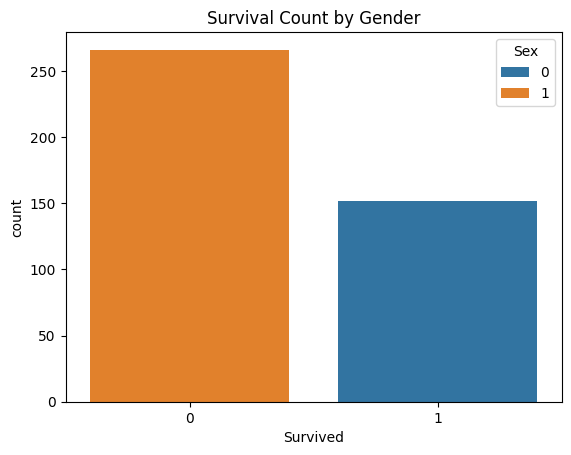

In [23]:
# Survival by gender
\
sns.countplot(x='Survived', hue='Sex', data=data)
plt.title('Survival Count by Gender')
plt.show()

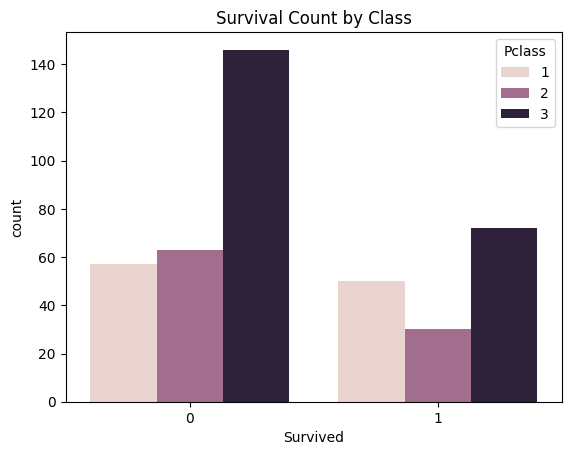

In [25]:
# Survival by class

sns.countplot(x='Survived', hue='Pclass', data=data)
plt.title('Survival Count by Class')
plt.show()

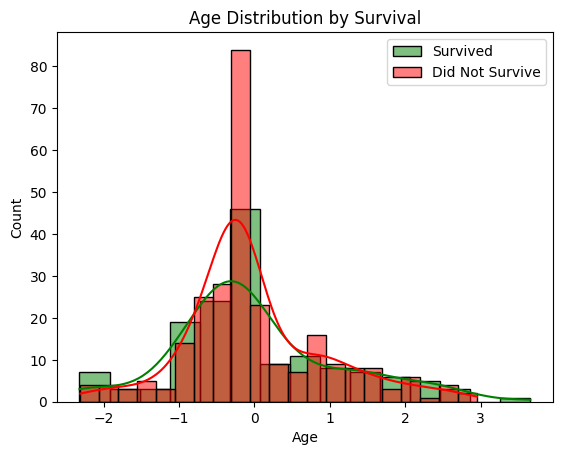

In [26]:
# Age distribution

sns.histplot(data[data['Survived'] == 1]['Age'], kde=True, color='green', label='Survived')
sns.histplot(data[data['Survived'] == 0]['Age'], kde=True, color='red', label='Did Not Survive')
plt.legend()
plt.title('Age Distribution by Survival')
plt.show()

# ESTIMATOR

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

class AgeIm(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.imputer = SimpleImputer(strategy="mean")

    def fit(self, x, y=None):
        self.imputer.fit(x[['Age']])
        return self

    def transform(self, x):
        x = x.copy()
        x['Age'] = self.imputer.transform(x[['Age']])
        return x

# Model Training and Evaluation

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [35]:
# Features and target

X = data.drop('Survived', axis=1)
y = data['Survived']

In [36]:
# Split data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(model)

RandomForestClassifier(random_state=42)


In [38]:
# Predict

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


# CONFUSION MATRIX

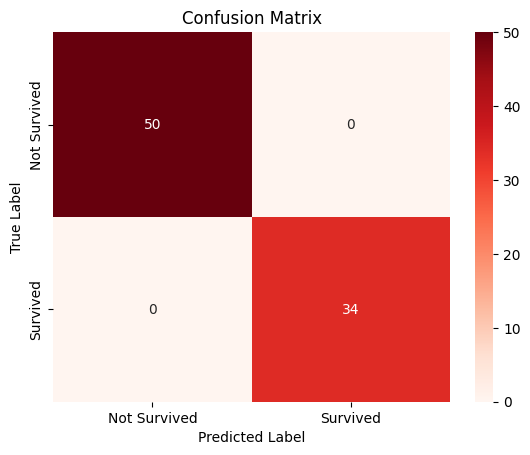

In [42]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Reds",xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# prediction

In [43]:
# Example new passenger (assuming all preprocessing already done!)
new_passenger = pd.DataFrame([{
    'Pclass': 3,
    'Sex': 0,            # male
    'Age': 22.0,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 7.25,
    'Embarked': 0        
}])

# Predict survival
prediction = model.predict(new_passenger)

# Output result
print("Prediction (0 = Not Survived, 1 = Survived):", prediction[0])


Prediction (0 = Not Survived, 1 = Survived): 1
